# Эксперимент 31: Data-driven dysarthria profiles

**Статья:** Data-Driven Classification of Dysarthria Profiles in Children (Классификация профилей дизартрии у детей на основе data-driven подхода) 2019

**Ссылка:** [https://pmc.ncbi.nlm.nih.gov/articles/PMC6440310/](https://pmc.ncbi.nlm.nih.gov/articles/PMC6440310/)

**Краткое описание модели:** MFCC-статистики и связанная акустика -> Random Forest для data-driven профилирования/классификации.

**Содержание статьи:** Статья поддерживает data-driven подход к стратификации профилей нарушений речи у детей. Она подчеркивает клиническую ценность автоматического выделения паттернов, а не только общей метки "норма/патология". В эксперименте используется RF как устойчивый baseline для профильно-ориентированной классификации.

In [ ]:
import sys
from pathlib import Path
import numpy as np
import time
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, precision_score, recall_score, classification_report

exp_dir = Path().resolve()
sys.path.insert(0, str(exp_dir.parent))

from shared import config, data_utils
from shared.results_utils import save_result_csv

## 1. Загрузка данных и разбиение

In [ ]:
paths_train, paths_val, paths_test, y_train, y_val, y_test, letters_train, letters_val, letters_test = data_utils.get_splits()
print(f"Train: {len(paths_train)}, Val: {len(paths_val)}, Test: {len(paths_test)}")
n_letters = letters_train.shape[1]

Train: 1942, Val: 417, Test: 417


## 2. Извлечение признаков

In [ ]:
extractor = lambda p: data_utils.extract_mfcc_stats(p)

## 3. Обучение, подбор гиперпараметров и оценка

Размер признакового вектора: 88
Fitting 5 folds for each of 8 candidates, totalling 40 fits
Лучшие параметры: {'clf__max_depth': 12, 'clf__min_samples_leaf': 5, 'clf__n_estimators': 400}


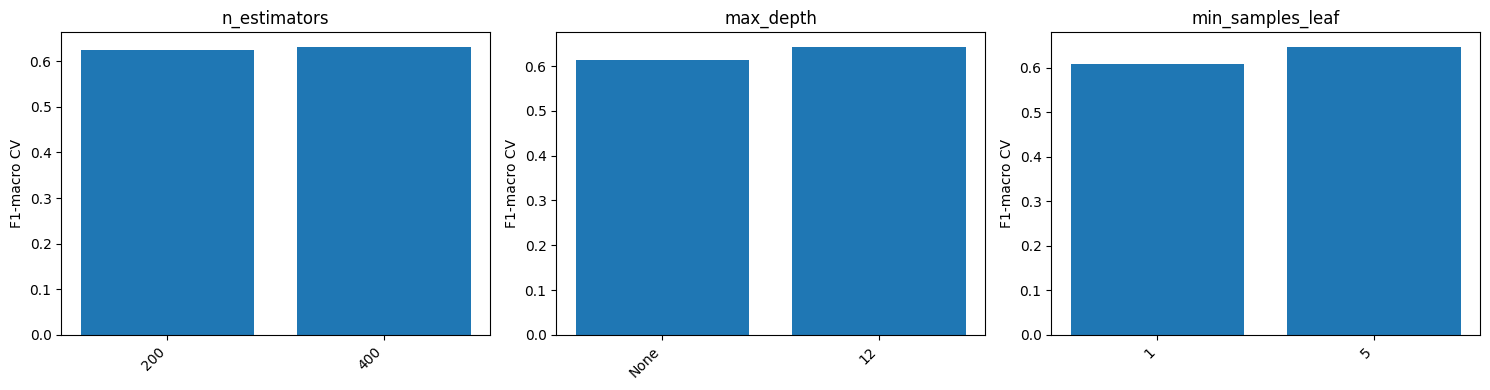

              precision    recall  f1-score   support

        good       0.77      0.91      0.83       282
         bad       0.69      0.43      0.53       135

    accuracy                           0.75       417
   macro avg       0.73      0.67      0.68       417
weighted avg       0.74      0.75      0.73       417



,accuracy,f1_macro,f1_bad,roc_auc,precision_bad,recall_bad
0,0.752998,0.6811,0.52968,0.740426,0.690476,0.42963


Результат сохранён в result.csv текущего эксперимента


In [ ]:
MODEL_TYPE = "rf"
EXPERIMENT_ID = "exp_31_dysarthria_profiles"
EXPERIMENT_NAME = "Data-driven dysarthria profiles"
MODEL_NAME = "Random Forest"
NOTES_PREFIX = "mfcc/grid="
X_train = data_utils.build_feature_matrix(paths_train, extractor, n_jobs=-1)
X_val   = data_utils.build_feature_matrix(paths_val, extractor, n_jobs=-1)
X_test  = data_utils.build_feature_matrix(paths_test, extractor, n_jobs=-1)
if letters_train.shape[1] > 0:
    X_train = np.hstack([X_train, letters_train])
    X_val   = np.hstack([X_val, letters_val])
    X_test  = np.hstack([X_test, letters_test])
print(f"Размер признакового вектора: {X_train.shape[1]}")

if MODEL_TYPE == "svm":
    classes = np.unique(y_train)
    weights = compute_class_weight("balanced", classes=classes, y=y_train)
    class_weight = dict(zip(classes, weights))
    base_model = SVC(kernel="rbf", class_weight=class_weight, probability=True, random_state=config.RANDOM_STATE)
    param_grid = {"clf__C": [0.1, 1.0, 10.0], "clf__gamma": ["scale", "auto"]}
else:
    base_model = RandomForestClassifier(class_weight="balanced", random_state=config.RANDOM_STATE, n_jobs=-1)
    param_grid = {"clf__n_estimators": [200, 400], "clf__max_depth": [None, 12], "clf__min_samples_leaf": [1, 5]}

pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", base_model),
])

grid = GridSearchCV(pipe, param_grid, cv=5, scoring="f1_macro", refit=True, n_jobs=-1, verbose=1)
t0 = time.perf_counter()
grid.fit(X_train, y_train)
train_time_sec = time.perf_counter() - t0
clf = grid.best_estimator_
print("Лучшие параметры:", grid.best_params_)

# График зависимости mean CV score от значений гиперпараметров
cv_results = grid.cv_results_
params = list(param_grid.keys())
fig, axes = plt.subplots(1, len(params), figsize=(5 * len(params), 4))
if len(params) == 1:
    axes = [axes]
for ax, pname in zip(axes, params):
    key = "param_" + pname
    vals = list(param_grid[pname])
    means = []
    for v in vals:
        mask = cv_results[key] == v
        means.append(np.mean(cv_results["mean_test_score"][mask]))
    ax.bar(range(len(vals)), means)
    ax.set_xticks(range(len(vals)))
    ax.set_xticklabels([str(v) for v in vals], rotation=45, ha="right")
    ax.set_title(pname.replace("clf__", ""))
    ax.set_ylabel("F1-macro CV")
plt.tight_layout(); plt.show()

y_pred = clf.predict(X_test)
y_proba = clf.predict_proba(X_test)[:, 1]
accuracy = accuracy_score(y_test, y_pred)
f1_macro = f1_score(y_test, y_pred, average="macro")
f1_bad = f1_score(y_test, y_pred, average="binary", pos_label=config.CLASS_BAD)
roc_auc = roc_auc_score(y_test, y_proba)
precision_bad = precision_score(y_test, y_pred, zero_division=0, pos_label=config.CLASS_BAD)
recall_bad = recall_score(y_test, y_pred, zero_division=0, pos_label=config.CLASS_BAD)

print(classification_report(y_test, y_pred, target_names=config.CLASS_NAMES))
metrics_table = pd.DataFrame([{
    "accuracy": accuracy,
    "f1_macro": f1_macro,
    "f1_bad": f1_bad,
    "roc_auc": roc_auc,
    "precision_bad": precision_bad,
    "recall_bad": recall_bad,
}])
display(metrics_table)

save_result_csv(
    exp_dir=exp_dir,
    experiment_id=EXPERIMENT_ID,
    experiment_name=EXPERIMENT_NAME,
    model=MODEL_NAME,
    accuracy=accuracy,
    f1_macro=f1_macro,
    f1_bad=f1_bad,
    roc_auc=roc_auc,
    precision_bad=precision_bad,
    recall_bad=recall_bad,
    notes=NOTES_PREFIX + str(grid.best_params_),
    num_params=None,
    train_time_sec=train_time_sec,
)